# Steam Games Analytics Dashboard
### *Exploratory Data Analysis and Business Insights using Python*

---

## Project Overview

This project explores a dataset of Steam games to uncover trends, patterns, and insights within one of the world's largest digital gaming platforms. Through data cleaning, visualization, and statistical analysis, this notebook demonstrates the complete workflow of transforming raw data into meaningful business insights.

The objective is to identify factors that influence game popularity, pricing, user engagement, and overall marketplace trends while showcasing practical data analytics techniques using Python.

---
> **Author:** Ptheusen Geagoni  
> **Field:** Computer Engineering • Data Analytics • Artificial Intelligence  
> **Project Type:** Portfolio Project

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
from dotenv import load_dotenv
 
load_dotenv()
 
DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD"),
    "database": os.getenv("DB_NAME"),
    "port": int(os.getenv("DB_PORT", 3306)),
    "ssl_ca": os.getenv("DB_SSL_CA", "ca.pem"),
}
 
conn = mysql.connector.connect(**DB_CONFIG)
print("Connected successfully.")
 

Connected successfully.


In [3]:
query = "SELECT * FROM games_clean"
df = pd.read_sql(query, conn)
 
print(f"Loaded {len(df)} rows.")
df.head()
 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32564\2465823846.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Loaded 377 rows.


,id,app_id,name,genre,price_usd,is_free,release_date,developer,current_players,pulled_at
0,1,578080,PUBG: BATTLEGROUNDS,Action,0.00,1,2017-12-21,PUBG Corporation,322892,2026-07-07 08:13:55
1,2,578080,PUBG: BATTLEGROUNDS,Adventure,0.00,1,2017-12-21,PUBG Corporation,322892,2026-07-07 08:13:55
2,3,578080,PUBG: BATTLEGROUNDS,Massively Multiplayer,0.00,1,2017-12-21,PUBG Corporation,322892,2026-07-07 08:13:55
3,4,578080,PUBG: BATTLEGROUNDS,Free To Play,0.00,1,2017-12-21,PUBG Corporation,322892,2026-07-07 08:13:55
4,5,1174180,Red Dead Redemption 2,Action,14.99,0,2019-12-05,Rockstar Games,26780,2026-07-07 08:13:55


In [4]:
print(f"Unique games: {df['app_id'].nunique()}")
print(f"Unique genres: {df['genre'].nunique()}")
print(f"Date range of pulled_at: {df['pulled_at'].min()} to {df['pulled_at'].max()}")
 
df['genre'].value_counts()
 

Unique games: 100
Unique genres: 16
Date range of pulled_at: 2026-07-07 08:13:55 to 2026-07-07 09:09:25


genre
Action                   101
Adventure                 55
Free To Play              40
RPG                       40
Indie                     37
Simulation                28
Massively Multiplayer     26
Strategy                  18
Casual                    11
Early Access               9
Sports                     7
Racing                     1
Animation & Modeling       1
Design & Illustration      1
Photo Editing              1
Utilities                  1
Name: count, dtype: int64

In [7]:
non_game_genres = ["Animation & Modeling", "Design & Illustration", "Photo Editing", "Utilities", "Video Production", "Audio Production", "Software Training"]
df_games_only = df[~df['genre'].isin(non_game_genres)]

print(f"Removed {len(df) - len(df_games_only)} rows tagged as non-game software.")

Removed 4 rows tagged as non-game software.


In [8]:
genre_avg_players = (
    df_games_only.groupby('genre')['current_players']
    .mean()
    .round(0)  # rounds to whole numbers for cleaner display
    .sort_values(ascending=False)
)
print(genre_avg_players)

genre
Free To Play             119133.0
Action                    60090.0
Massively Multiplayer     57970.0
Strategy                  55950.0
Adventure                 43881.0
RPG                       29478.0
Indie                     25564.0
Early Access              20192.0
Simulation                19940.0
Casual                    17219.0
Sports                     7496.0
Racing                     7362.0
Name: current_players, dtype: float64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32564\1315110103.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_avg_players.values, y=genre_avg_players.index, palette="viridis")


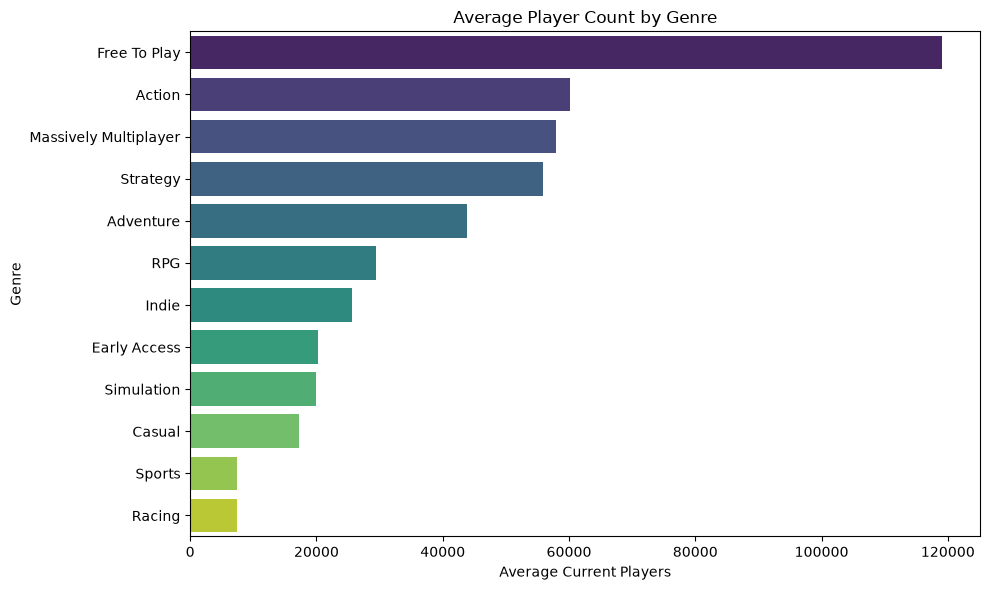

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_avg_players.values, y=genre_avg_players.index, palette="viridis")
plt.xlabel("Average Current Players")
plt.ylabel("Genre")
plt.title("Average Player Count by Genre")
plt.tight_layout()
plt.show()

In [10]:
genre_stats = (
    df_games_only.groupby('genre')['current_players']
    .agg(['mean', 'median', 'count'])
    .round(0)
    .sort_values('mean', ascending=False)
)
print(genre_stats)

                           mean   median  count
genre                                          
Free To Play           119133.0  36458.0     40
Action                  60090.0  17056.0    101
Massively Multiplayer   57970.0   5287.0     26
Strategy                55950.0   9058.0     18
Adventure               43881.0  18455.0     55
RPG                     29478.0  22160.0     40
Indie                   25564.0  13304.0     37
Early Access            20192.0  15657.0      9
Simulation              19940.0  11784.0     28
Casual                  17219.0   4727.0     11
Sports                   7496.0    541.0      7
Racing                   7362.0   7362.0      1


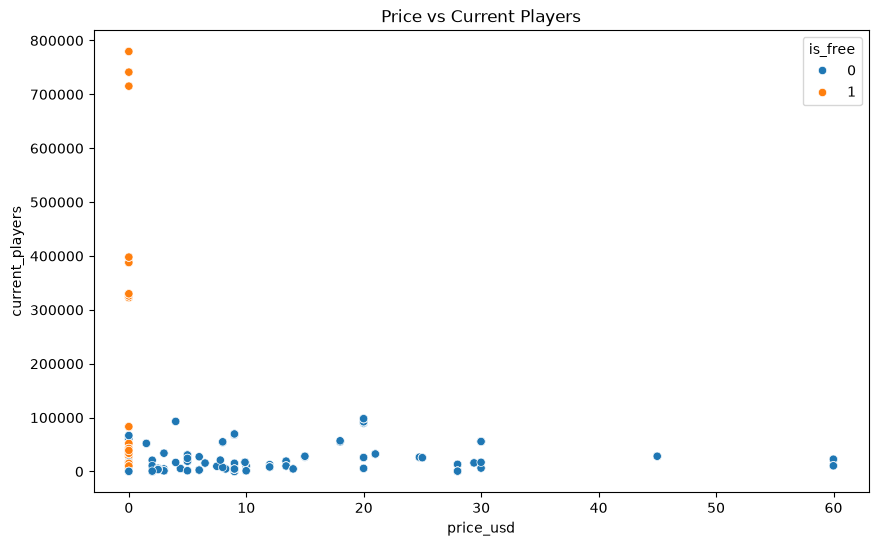

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_games_only, x='price_usd', y='current_players', hue='is_free')
plt.title("Price vs Current Players")
plt.show()

In [13]:
top_games = (
    df_games_only.groupby('name')['current_players']
    .max()
    .sort_values(ascending=False)
    .head(10)
)
print(top_games)

name
Counter-Strike 2             779576
Dota 2                       397944
PUBG: BATTLEGROUNDS          329900
Rust                          98042
Wallpaper Engine              92950
Apex Legends™                 83292
Stardew Valley                69690
Grand Theft Auto V Legacy     66808
Cyberpunk 2077                57024
Path of Exile 2               55669
Name: current_players, dtype: int64


In [14]:
free_vs_paid = df_games_only.groupby('is_free')['current_players'].mean().round(0)
print(free_vs_paid)

is_free
0    23886.0
1    97173.0
Name: current_players, dtype: float64
